# Eksperimen Sistem Machine Learning: Heart Disease Classification
**Nama:** Davin Putra Fibrian  
**Target Submission:** Kriteria 1 - Eksperimen Dataset (Basic Tier)  
**Dataset:** Heart Disease UCI / Kaggle Tabular Dataset (~1.025 baris, 13 fitur klinis)

---
### Ringkasan Alur Eksperimen:
1. **Data Loading:** Membaca dataset mentah dari folder `heart_disease_raw/`.
2. **Exploratory Data Analysis (EDA):** Analisis tipe data, sebaran target, korelasi antar fitur, dan distribusi fitur klinis.
3. **Data Preprocessing:** Validasi kelengkapan data, standarisasi fitur numerik kontinu (*StandardScaler*), dan stratified splitting (80:20) untuk mencegah overfitting.
4. **Export Clean Data:** Menyimpan dataset bersih ke folder `heart_disease_preprocessing/data_clean.csv` untuk tahap modelling.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Library berhasil diimport.")

Library berhasil diimport.


## 1. Data Loading
Memuat dataset mentah `heart_disease.csv` dari folder `../heart_disease_raw/`.

In [2]:
data_path = os.path.join("..", "heart_disease_raw", "heart_disease.csv")
df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Dataset Shape: 1025 baris, 14 kolom


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,58,1,0,139,301,0,1,75,1,0.6,1,0,2,0
1,53,0,1,137,321,0,1,128,1,1.9,2,0,3,0
2,60,0,0,104,198,0,1,145,0,0.4,2,0,2,1
3,68,1,0,133,202,0,1,142,1,0.6,2,3,2,0
4,52,1,0,126,238,0,1,146,0,0.9,1,3,2,0


## 2. Exploratory Data Analysis (EDA)
Memeriksa informasi tipe data, missing values, statistik deskriptif, dan visualisasi distribusi.

In [3]:
print("=== Informasi Dataset ===")
df.info()

print("\n=== Pengecekan Missing Values ===")
print(df.isnull().sum())

print("\n=== Statistik Deskriptif ===")
df.describe()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

=== Pengecekan Missing Values ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
c

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000
mean,54.183415,0.699512,0.935610,131.504390,242.335610,0.150244,0.511220,148.047805,0.332683,1.078244,1.397073,0.731707,2.33561,0.453659
std,8.756890,0.458694,1.026861,17.562395,50.636077,0.357485,0.521155,24.242683,0.471404,0.885145,0.610289,1.023751,0.58676,0.498091
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,75.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000
25%,48.000000,0.000000,0.000000,119.000000,208.000000,0.000000,0.000000,131.000000,0.000000,0.400000,1.000000,0.000000,2.00000,0.000000
50%,54.000000,1.000000,1.000000,131.000000,243.000000,0.000000,1.000000,148.000000,0.000000,0.900000,1.000000,0.000000,2.00000,0.000000
75%,60.000000,1.000000,2.000000,143.000000,276.000000,0.000000,1.000000,165.000000,1.000000,1.600000,2.000000,1.000000,3.00000,1.000000
max,77.000000,1.000000,3.000000,200.000000,413.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.00000,1.000000


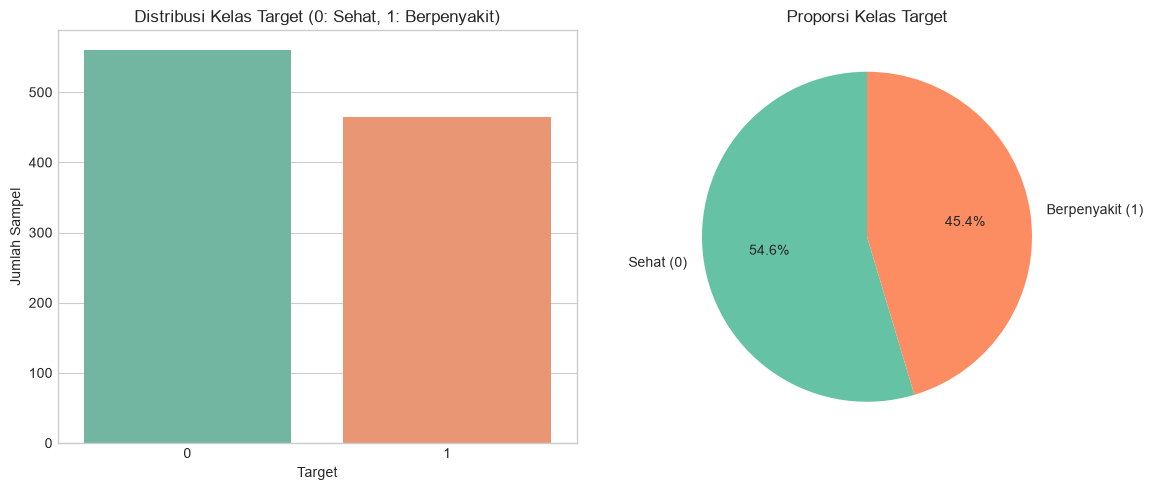

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart
sns.countplot(data=df, x='target', hue='target', palette='Set2', legend=False, ax=ax[0])
ax[0].set_title('Distribusi Kelas Target (0: Sehat, 1: Berpenyakit)')
ax[0].set_xlabel('Target')
ax[0].set_ylabel('Jumlah Sampel')

# Pie Chart
target_counts = df['target'].value_counts()
ax[1].pie(target_counts, labels=['Sehat (0)', 'Berpenyakit (1)'], autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
ax[1].set_title('Proporsi Kelas Target')

plt.tight_layout()
plt.show()

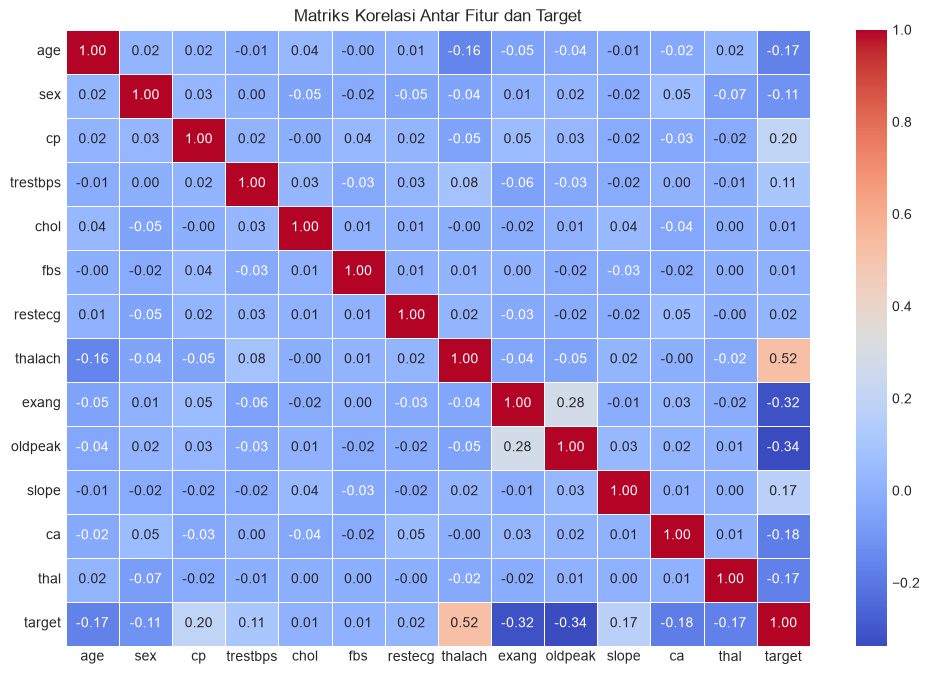

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Antar Fitur dan Target')
plt.show()

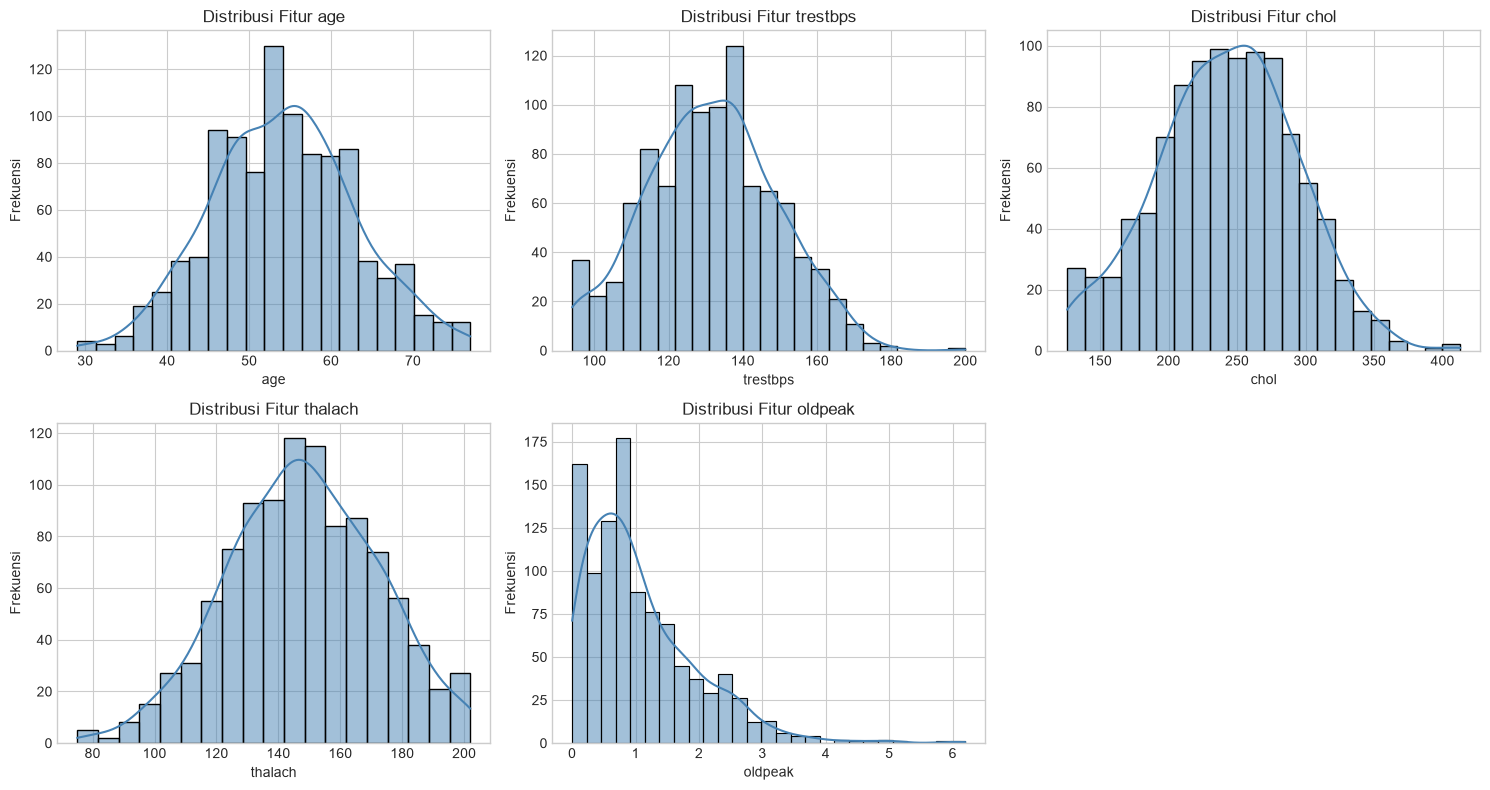

In [6]:
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi Fitur {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

# Sembunyikan subplot ke-6 yang kosong
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Feature Engineering
Melakukan pembersihan data, standarisasi fitur numerik, dan pemisahan data (Train-Test Split) dengan teknik Stratified Sampling.

In [7]:
# Verifikasi dan penanganan missing values jika ada
if df.isnull().sum().sum() == 0:
    print("Dataset 100% lengkap tanpa missing values.")
else:
    df = df.dropna()
    print("Missing values berhasil dibersihkan.")

Dataset 100% lengkap tanpa missing values.


In [8]:
# Pisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['target']).copy()
y = df['target'].copy()

# Standarisasi fitur kontinu menggunakan StandardScaler
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[continuous_cols] = scaler.fit_transform(X[continuous_cols])

print("Sampel fitur setelah standarisasi:")
X_scaled.head()

Sampel fitur setelah standarisasi:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.436051,1,0,0.427007,1.159115,0,1,-3.014661,1,-0.540564,1,0,2
1,-0.135207,0,1,0.313072,1.554283,0,1,-0.827367,1,0.928839,2,0,3
2,0.664554,0,0,-1.566860,-0.876001,0,1,-0.125782,0,-0.766626,2,0,2
3,1.578566,1,0,0.085201,-0.796967,0,1,-0.249591,1,-0.540564,2,3,2
4,-0.249458,1,0,-0.313572,-0.085665,0,1,-0.084512,0,-0.201471,1,3,2


In [9]:
# Stratified Split 80:20 untuk menjamin proporsi target seimbang dan mencegah overfitting
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Latih (Train Set): {X_train.shape[0]} baris")
print(f"Data Uji (Test Set)   : {X_test.shape[0]} baris")
print("Distribusi Target Train:", y_train.value_counts(normalize=True).to_dict())
print("Distribusi Target Test :", y_test.value_counts(normalize=True).to_dict())

Data Latih (Train Set): 820 baris
Data Uji (Test Set)   : 205 baris
Distribusi Target Train: {0: 0.5463414634146342, 1: 0.45365853658536587}
Distribusi Target Test : {0: 0.5463414634146342, 1: 0.45365853658536587}


## 4. Export Clean Dataset
Menyimpan data hasil standarisasi ke dalam folder `heart_disease_preprocessing/data_clean.csv`.

In [10]:
df_clean = X_scaled.copy()
df_clean['target'] = y

output_dir = "heart_disease_preprocessing"
os.makedirs(output_dir, exist_ok=True)
clean_csv_path = os.path.join(output_dir, "data_clean.csv")
df_clean.to_csv(clean_csv_path, index=False)

print(f"Data bersih berhasil disimpan ke: {clean_csv_path}")
print(f"Dimensi data bersih: {df_clean.shape}")

Data bersih berhasil disimpan ke: heart_disease_preprocessing\data_clean.csv
Dimensi data bersih: (1025, 14)
